# Analisis Sentimen

In [1]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from tqdm import tqdm

## Labelling dan Pre-Processing

In [136]:
df = pd.read_csv('redmi6.csv', encoding='latin1')
df = df.dropna(subset=['Comments'])  # Ganti 'comment' sesuai nama kolom
comments = df['Comments'].astype(str).tolist()

# Load model & tokenizer
model_name = "finiteautomata/bertweet-base-sentiment-analysis"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Buat pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Analisis komentar
labels = []
scores = []

for comment in tqdm(comments, desc="Labeling komentar"):
    try:
        result = sentiment_pipeline(comment)[0]
        labels.append(result['label'])  # Output: POS / NEG / NEU
        scores.append(result['score'])  # Confidence score
    except:
        labels.append("NEU")  # Default jika gagal
        scores.append(0.0)

# Tambahkan ke DataFrame
df['bert_label'] = labels
df['bert_score'] = scores

# Simpan hasil
df.to_csv('redmi6_bert_sentiment.csv', index=False)
print("✅ Berhasil! File disimpan: redmi6_bert_sentiment.csv")


Device set to use cpu
Labeling komentar: 100%|██████████| 280/280 [00:10<00:00, 27.48it/s]

✅ Berhasil! File disimpan: redmi6_bert_sentiment.csv


In [302]:
df = pd.read_csv('redmi6_bert_sentiment.csv')
df


,Review Title,Customer name,Rating,Date,Category,Comments,Useful,bert_label,bert_score
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,,NEU,0.000000
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,NEU,0.589228
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful,POS,0.968431
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,NEU,0.000000
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,NEG,0.981726
...,...,...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5.0 out of 5 stars,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN,POS,0.991940
276,Mi is best phone,Sunil Soni,4.0 out of 5 stars,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN,NEU,0.972903
277,Its a OK Phone,D.C.Padhi,3.0 out of 5 stars,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN,NEU,0.000000
278,Redmi,Mahesh,5.0 out of 5 stars,on 21 September 2018,Others,I love mi,NaN,POS,0.991739


In [232]:
sentiment_counts = df['bert_label'].value_counts()
print(sentiment_counts)

bert_label
POS    175
NEG     56
NEU     49
Name: count, dtype: int64


In [171]:
def extract_useful_number(text):
    text = str(text).lower().strip()
    if "no one" in text:
        return 0
    elif "one" in text:
        return 1
    else:
        # Ambil angka di depan
        try:
            return int(text.split()[0])
        except:
            return 0

# Terapkan ke kolom
df['useful_count'] = df['Useful'].apply(extract_useful_number)

In [178]:
# Bersihkan kolom Rating agar bisa diproses numerik
df['Rating_clean'] = df['Rating'].str.extract(r'(\d\.\d)').astype(float)

## EDA Sederhana

Distribusi Rating:
 Rating_clean
1.0     43
2.0      9
3.0     27
4.0     50
5.0    151
Name: count, dtype: int64


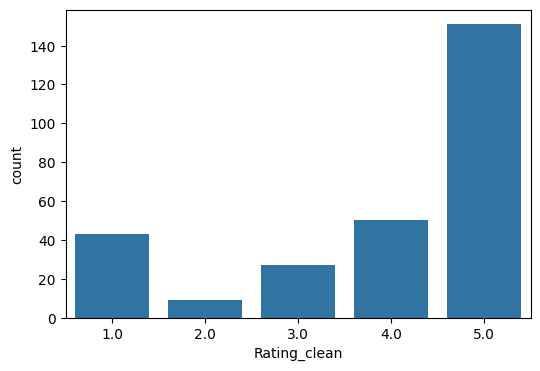

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- EDA: Distribusi Rating ---
rating_counts = df['Rating_clean'].value_counts().sort_index()
print("Distribusi Rating:\n", rating_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='Rating_clean', data=df)
plt.show()

In [181]:
# --- EDA: Jumlah Review per Kategori ---
category_counts = df['Category'].value_counts()
print("\nJumlah Review per Kategori:\n", category_counts)


Jumlah Review per Kategori:
 Category
Others      180
Display      36
Battery      29
Camera       28
Delivery      7
Name: count, dtype: int64


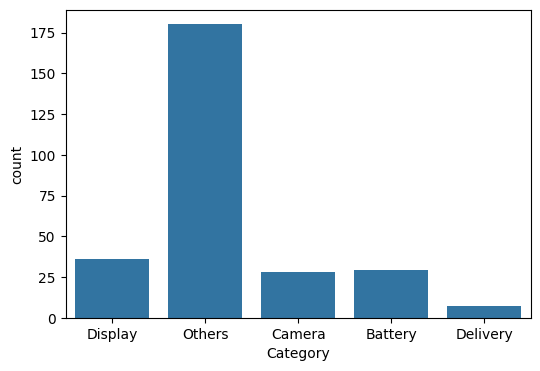

In [182]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Category', data=df)
plt.show()

In [183]:
# Hitung distribusi label sentimen otomatis
sentiment_counts = df['bert_label'].value_counts()

# Tampilkan hasil distribusi sentimen
sentiment_counts


bert_label
POS    175
NEG     56
NEU     49
Name: count, dtype: int64

## Model Klasifikasi

In [303]:
# 1. Import library
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 3. Gunakan label hasil analisis sentimen otomatis
df = df.dropna(subset=['Comments', 'bert_label'])

# 4. Fitur dan Target
X = df['Comments'].astype(str)
y = df['bert_label']

# 5. TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_tfidf = vectorizer.fit_transform(X)

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# 7. Logistic Regression
lr = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 8. Support Vector Classifier (SVC)
svc = SVC(kernel='linear', probability=True)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

# 9. Evaluasi Logistic Regression
print("📌 Logistic Regression:")
print("Akurasi:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# 10. Evaluasi SVC
print("\n📌 Support Vector Classifier:")
print("Akurasi:", accuracy_score(y_test, y_pred_svc))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))


📌 Logistic Regression:
Akurasi: 0.7857142857142857

Classification Report:
               precision    recall  f1-score   support

         NEG       1.00      0.45      0.62        11
         NEU       1.00      0.40      0.57        10
         POS       0.74      1.00      0.85        35

    accuracy                           0.79        56
   macro avg       0.91      0.62      0.68        56
weighted avg       0.84      0.79      0.76        56

Confusion Matrix:
 [[ 5  0  6]
 [ 0  4  6]
 [ 0  0 35]]

📌 Support Vector Classifier:
Akurasi: 0.875

Classification Report:
               precision    recall  f1-score   support

         NEG       0.78      0.64      0.70        11
         NEU       1.00      0.70      0.82        10
         POS       0.88      1.00      0.93        35

    accuracy                           0.88        56
   macro avg       0.88      0.78      0.82        56
weighted avg       0.88      0.88      0.87        56

Confusion Matrix:
 [[ 7  0  4]
 [ 2 

ROC AUC Score (macro-average): 0.8941


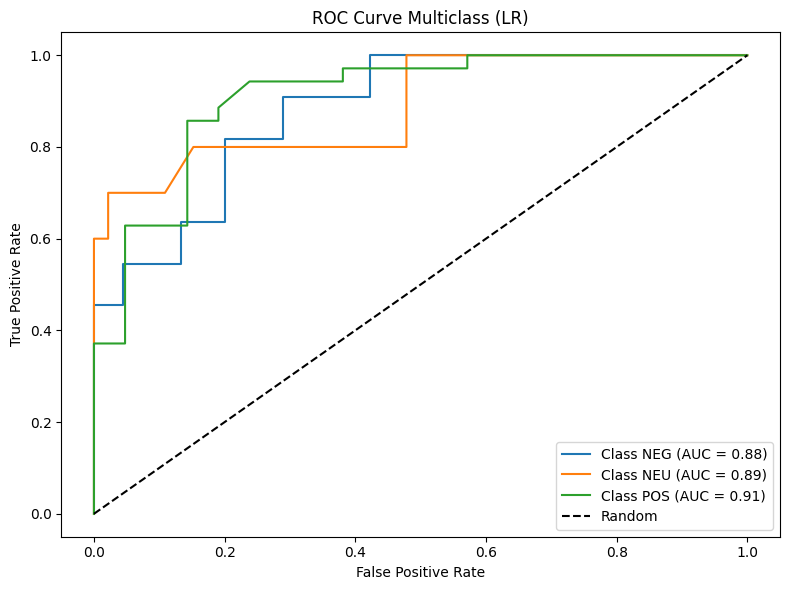

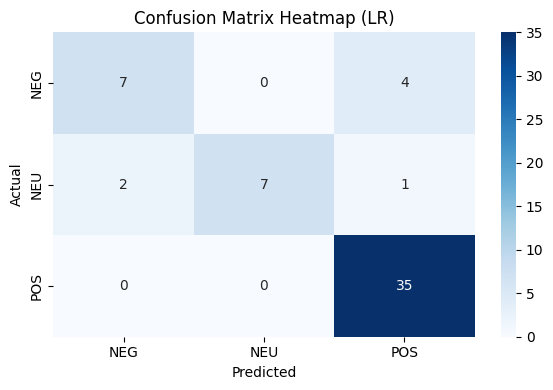

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

# 1. Binarisasi label untuk ROC (One-vs-Rest)
classes = list(svc.classes_)  
y_test_bin = label_binarize(y_test, classes=classes)
y_score = lr.decision_function(X_test)  # gunakan LR model

# 2. Hitung ROC AUC
roc_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print(f"ROC AUC Score (macro-average): {roc_auc:.4f}")

# 3. Plot ROC Curve untuk tiap kelas
plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve Multiclass (LR)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Heatmap Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svc, labels=classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap (LR)')
plt.tight_layout()
plt.show()


ROC AUC Score (macro-average): 0.8970


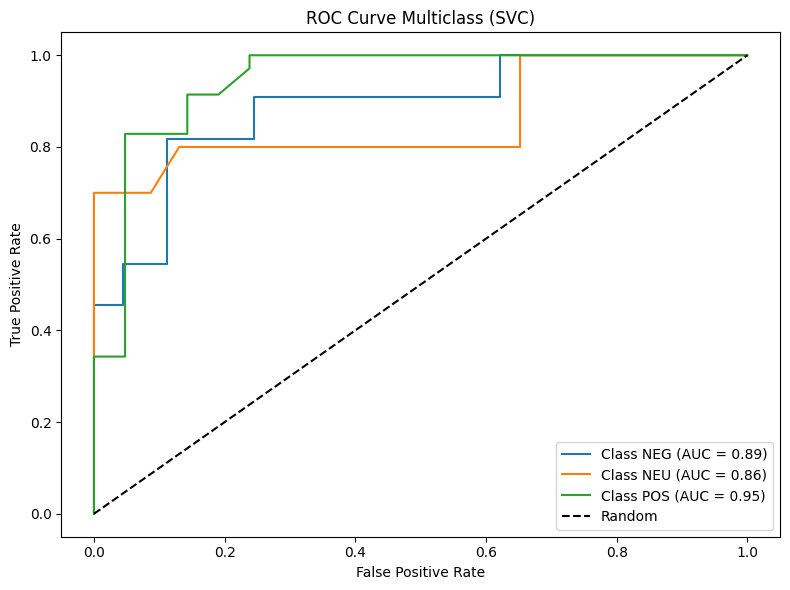

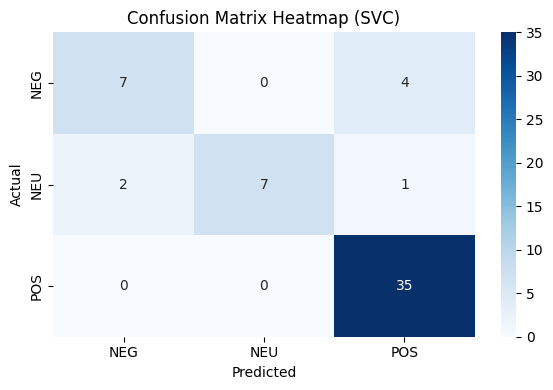

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

# 1. Binarisasi label untuk ROC (One-vs-Rest)
classes = list(svc.classes_)  
y_test_bin = label_binarize(y_test, classes=classes)
y_score = svc.decision_function(X_test)  # gunakan SVC model

# 2. Hitung ROC AUC
roc_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print(f"ROC AUC Score (macro-average): {roc_auc:.4f}")

# 3. Plot ROC Curve untuk tiap kelas
plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve Multiclass (SVC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Heatmap Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svc, labels=classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap (SVC)')
plt.tight_layout()
plt.show()


### Analisis Lanjutan

In [304]:
# 1. Ambil indeks komentar uji
X_test_text = X.iloc[y_test.index]  # ambil teks aslinya dari X

# 2. Buat DataFrame hasil prediksi
result_df = pd.DataFrame({
    'Comments': X_test_text.values,
    'Actual': y_test.values,
    'Predicted': y_pred_svc
})

# 3. Filter hanya yang salah prediksi
wrong_preds = result_df[result_df['Actual'] != result_df['Predicted']]

# 4. Tampilkan
print(f"Jumlah salah prediksi: {len(wrong_preds)}")
wrong_preds.head(10)  # tampilkan 10 teratas dulu


Jumlah salah prediksi: 7


,Comments,Actual,Predicted
8,Front camera is poor rest things are good,NEU,NEG
9,"Awesome sound quality , battery life is good ,...",NEG,POS
13,"Awesome sound quality , battery life is good ,...",NEG,POS
17,Front camera is poor rest things are good,NEU,NEG
23,No,NEU,POS
31,Sound quality is not so good\nEither way the m...,NEG,POS
38,Same old configurations with higher price.\nNo...,NEG,POS


In [189]:
from IPython.display import display
import pandas as pd

# Ambil 6 contoh komentar yang salah diprediksi
sample_wrong = wrong_preds.head(6).copy()

# Tambahkan nomor
sample_wrong.insert(0, "No", range(1, 1 + len(sample_wrong)))

# Batasi panjang komentar untuk visualisasi
sample_wrong["Short_Comment"] = sample_wrong["Comments"].apply(lambda x: x[:80] + "..." if len(x) > 80 else x)

# Pilih kolom untuk ditampilkan
display(sample_wrong[["No", "Short_Comment", "Actual", "Predicted"]])


,No,Short_Comment,Actual,Predicted
8,1,Front camera is poor rest things are good,NEU,NEG
9,2,"Awesome sound quality , battery life is good ,...",NEG,POS
13,3,"Awesome sound quality , battery life is good ,...",NEG,POS
17,4,Front camera is poor rest things are good,NEU,NEG
23,5,No,NEU,POS
31,6,Sound quality is not so good\nEither way the m...,NEG,POS


In [199]:
# Komentar uji coba baru
test_comments = [
    "Worst phone ever. Hangs all the time.",                # NEG
    "Good value for money, decent performance",             # POS
    "Just average, nothing exciting here.",                 # NEU
    "Camera is terrible, not worth the price",              # NEG
    "Great sound, fast processor, value for money!",        # POS
    "Like the model, but not for the performance"           # NEU
]

# Transform ke bentuk TF-IDF
test_vectors = vectorizer.transform(test_comments)

# Prediksi dengan model SVC
test_preds = svc.predict(test_vectors)

# Tampilkan hasil
for comment, pred in zip(test_comments, test_preds):
    print(f"[{pred}] {comment}")


[NEG] Worst phone ever. Hangs all the time.
[POS] Good value for money, decent performance
[NEU] Just average, nothing exciting here.
[NEG] Camera is terrible, not worth the price
[POS] Great sound, fast processor, value for money!
[NEU] Like the model, but not for the performance


🔍 10 Kata Paling Sering Muncul dalam Komentar NEGATIF:
camera         4
poor           4
worst          3
buy            3
performance    3
money          3
redmi          2
rest           2
quality        2
sim            2
dtype: int64


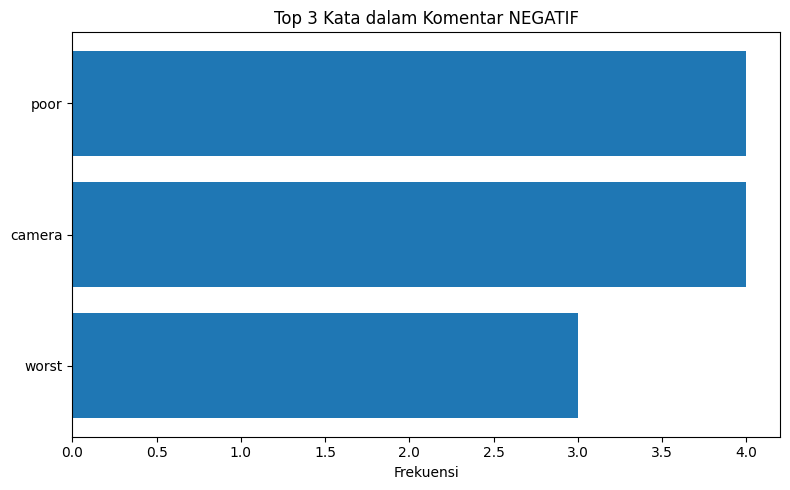

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Ambil index komentar yang diprediksi NEG oleh SVC
neg_indices = y_test.index[y_pred_svc == 'NEG']
neg_comments = X.iloc[neg_indices]  # komentar asli

# Buat CountVectorizer
cv = CountVectorizer(stop_words='english', max_features=100)
X_counts = cv.fit_transform(neg_comments)

# Buat DataFrame frekuensi kata
word_freq = pd.DataFrame(X_counts.toarray(), columns=cv.get_feature_names_out())

# Ambil 10 kata paling sering
word_sum = word_freq.sum().sort_values(ascending=False).head(3).sort_values(ascending=True)

# Cek kata paling sering dari seluruh komentar negatif (tanpa potong 10)
all_word_sum = word_freq.sum().sort_values(ascending=False)
print("🔍 3 Kata Paling Sering Muncul dalam Komentar NEGATIF:")
print(all_word_sum.head(10))  # lihat top 5 asli

# Visualisasi
plt.figure(figsize=(8, 5))
plt.barh(word_sum.index, word_sum.values)
plt.xlabel("Frekuensi")
plt.title("Top 3 Kata dalam Komentar NEGATIF")
plt.tight_layout()
plt.show()


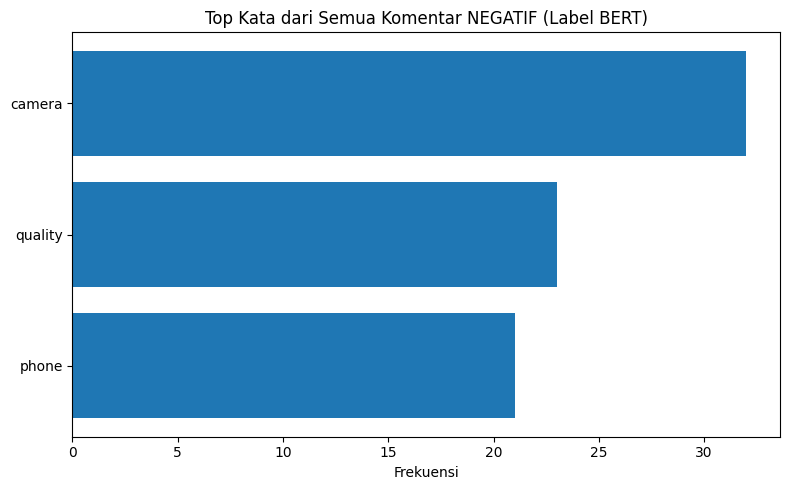

In [307]:
# Filter komentar negatif berdasarkan label BERT
neg_df = df[df['bert_label'] == 'NEG']

# Ambil komentar negatif sebagai list
neg_comments = neg_df['Comments'].astype(str).tolist()

# Hitung frekuensi kata
cv = CountVectorizer(stop_words='english', max_features=30)
X_counts = cv.fit_transform(neg_comments)

# Buat DataFrame dari frekuensi kata
word_freq = pd.DataFrame(X_counts.toarray(), columns=cv.get_feature_names_out())
word_sum = word_freq.sum().sort_values(ascending=False).head(3).sort_values(ascending=True)

# Visualisasi horizontal barchart
plt.figure(figsize=(8, 5))
plt.barh(word_sum.index, word_sum.values)
plt.xlabel("Frekuensi")
plt.title("Top Kata dari Semua Komentar NEGATIF (Label BERT)")
plt.tight_layout()
plt.show()

In [309]:
# Contoh: tampilkan komentar negatif yang mengandung kata "camera"
keyword = "camera"

# Filter komentar bert_label NEG yang mengandung keyword
mask = (df['bert_label'] == 'NEG') & (df['Comments'].str.contains(keyword, case=False, na=False))
camera_comments = df[mask][['Comments', 'Category', 'Rating']]

# Tampilkan hasil
print(f"🔍 Komentar NEGATIF yang mengandung kata: '{keyword}'")
print(f"Jumlah komentar: {len(camera_comments)}")
camera_comments.head(10)

🔍 Komentar NEGATIF yang mengandung kata: 'camera'
Jumlah komentar: 23


,Comments,Category,Rating
27,Camera clarity is not good and average mobile ...,Camera,3.0 out of 5 stars
37,Bad camera quality and heating problem,Camera,2.0 out of 5 stars
39,"Awesome sound quality , battery life is good ,...",Battery,3.0 out of 5 stars
47,Bad camera quality and heating problem,Camera,2.0 out of 5 stars
49,"Awesome sound quality , battery life is good ,...",Battery,3.0 out of 5 stars
53,Please dont't bye camera is good but battery b...,Battery,1.0 out of 5 stars
56,Both Camera quality is bed.its price is too hi...,Camera,1.0 out of 5 stars
91,No change in camera quality. Other functions s...,Camera,5.0 out of 5 stars
97,Looking wise sexy but camera quality is not wo...,Camera,4.0 out of 5 stars
218,It has a worst front camera I have ever seen o...,Camera,1.0 out of 5 stars


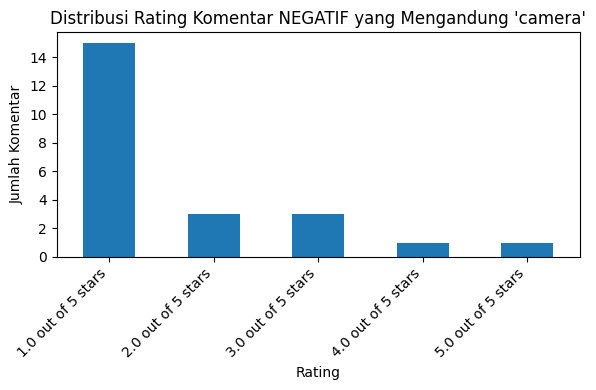

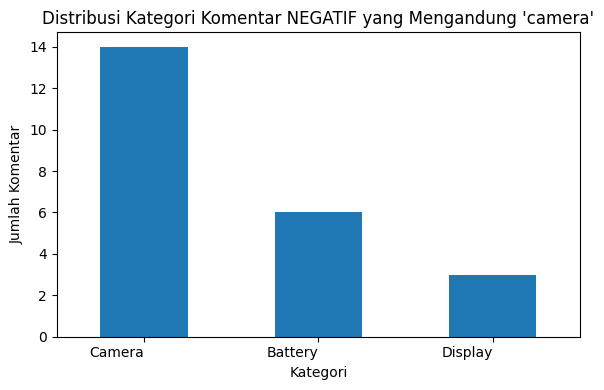

In [237]:
# Filter komentar yang mengandung kata "camera" dan labelnya NEG
camera_mask = (df['bert_label'] == 'NEG') & (df['Comments'].str.contains("camera", case=False, na=False))
camera_df = df[camera_mask]

# Plot 1: Distribusi Rating pada komentar yang mengandung kata "camera"
plt.figure(figsize=(6, 4))
camera_df['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribusi Rating Komentar NEGATIF yang Mengandung 'camera'")
plt.xlabel("Rating")
plt.ylabel("Jumlah Komentar")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 2: Distribusi Category pada komentar yang mengandung kata "camera"
plt.figure(figsize=(6, 4))
camera_df['Category'].value_counts().plot(kind='bar')
plt.title("Distribusi Kategori Komentar NEGATIF yang Mengandung 'camera'")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Komentar")
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()


Jumlah komentar NEGATIF dengan kategori 'Others': 28


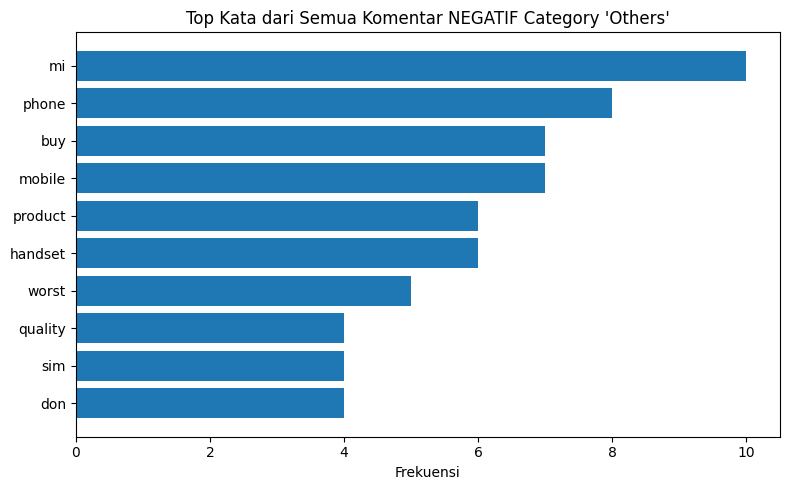

In [241]:
# Filter komentar negatif dengan kategori "Others"
others_neg_df = df[(df['bert_label'] == 'NEG') & (df['Category'].str.lower() == 'others')]

# Tampilkan isi komentarnya
print(f"Jumlah komentar NEGATIF dengan kategori 'Others': {len(others_neg_df)}")
others_neg_df[['Comments', 'Rating']].head(10)  # tampilkan 10 komentar pertama

# Ambil komentar negatif sebagai list
neg_comments = others_neg_df['Comments'].astype(str).tolist()

# Hitung frekuensi kata
cv = CountVectorizer(stop_words='english', max_features=30)
X_counts = cv.fit_transform(neg_comments)

# Buat DataFrame dari frekuensi kata
word_freq = pd.DataFrame(X_counts.toarray(), columns=cv.get_feature_names_out())
word_sum = word_freq.sum().sort_values(ascending=False).head(10).sort_values(ascending=True)

# Visualisasi horizontal barchart
plt.figure(figsize=(8, 5))
plt.barh(word_sum.index, word_sum.values)
plt.xlabel("Frekuensi")
plt.title("Top Kata dari Semua Komentar NEGATIF Category 'Others'")
plt.tight_layout()
plt.show()


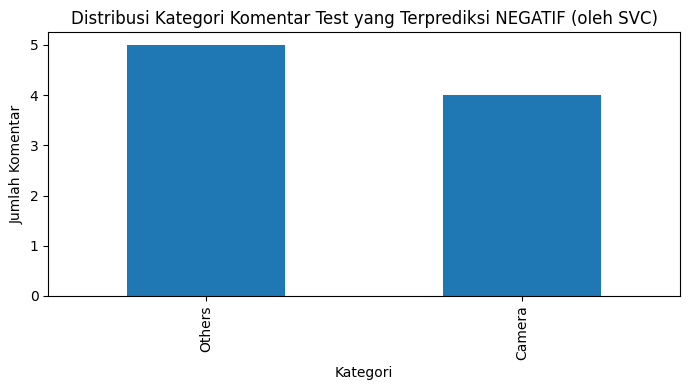

In [244]:
# Prediksi
y_pred_svc = svc.predict(X_test)

# Ambil index test
test_indices = y_test.index

# Ambil indeks komentar test yang diprediksi NEG
neg_test_idx = test_indices[np.where(y_pred_svc == 'NEG')[0]]

# Ambil baris dari dataframe asli
neg_test_df = df.loc[neg_test_idx]

# Plot distribusi Category
plt.figure(figsize=(7, 4))
neg_test_df['Category'].value_counts().plot(kind='bar')
plt.title("Distribusi Kategori Komentar Test yang Terprediksi NEGATIF (oleh SVC)")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Komentar")
plt.tight_layout()
plt.show()

In [247]:
# Filter category Others
others_neg_test_df = neg_test_df[neg_test_df['Category'].str.lower() == 'others']

# Tampilkan seluruh data
others_neg_test_df[['Comments', 'Category', 'Rating']]

,Comments,Category,Rating
69,Worst phone,Others,1.0 out of 5 stars
143,waste of money,Others,1.0 out of 5 stars
266,Do not buy.,Others,1.0 out of 5 stars
57,I have purchsed this item and two jio sim are ...,Others,1.0 out of 5 stars
96,Sound qulity not dolby and processor performan...,Others,3.0 out of 5 stars


Category
Others      28
Camera      14
Battery      8
Display      5
Delivery     1
Name: count, dtype: int64


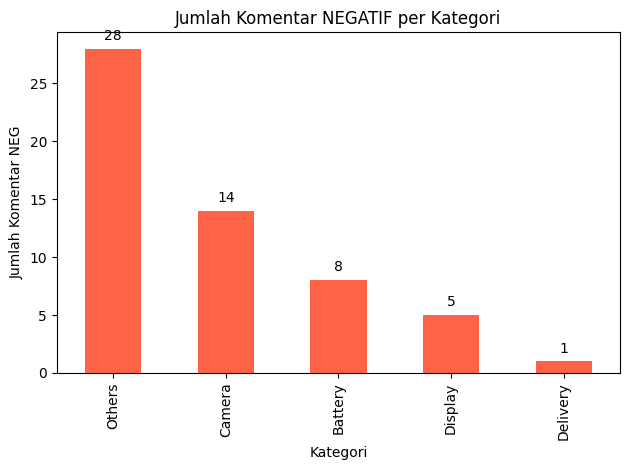

In [170]:
# Filter komentar yang berlabel NEG
neg_df = df[df['bert_label'] == 'NEG']

# Hitung jumlah komentar NEG per kategori
neg_per_category = neg_df['Category'].value_counts()

# Tampilkan hasil
print(neg_per_category)
neg_per_category.plot(kind='bar', color='tomato', title='Jumlah Komentar NEGATIF per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Komentar NEG')
plt.tight_layout()
# Tambahkan label angka di atas bar
for i, v in enumerate(neg_per_category):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10)
plt.show()
plt.show()

## Analisis Lanjutan Sentimen Negative Customer Feedback

In [7]:
negative_comments = df[df['bert_label'] == 'NEG']['Comments'].dropna().astype(str)

In [8]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # hapus link
    text = re.sub(r"[^a-z\s]", "", text)  # hapus angka dan simbol
    text = re.sub(r"\s+", " ", text)  # hapus spasi ganda
    return text.strip()

cleaned_comments = negative_comments.apply(clean_text)


In [10]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')
X = model.encode(cleaned_comments.tolist())

In [12]:
from sklearn.cluster import KMeans

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

c:\Users\71477\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [15]:
negative_comments['cluster'] = labels

In [ ]:
print(negative_comments)

4          worst product from MI. I am a hardcore fan of ...
14         worst product from MI. I am a hardcore fan of ...
22         Like every things but fullscreen video playing...
23         Please don't buy these product.. I have 3-mobi...
27         Camera clarity is not good and average mobile ...
33                                               Do not buy.
37                    Bad camera quality and heating problem
39         Awesome sound quality , battery life is good ,...
43                                               Do not buy.
47                    Bad camera quality and heating problem
49         Awesome sound quality , battery life is good ,...
53         Please dont't bye camera is good but battery b...
55         Worst phone from MI and Amazon\nTouch was not ...
56         Both Camera quality is bed.its price is too hi...
57         I have purchsed this item and two jio sim are ...
61         Good phone but not value for money, Prefer Red...
63                      

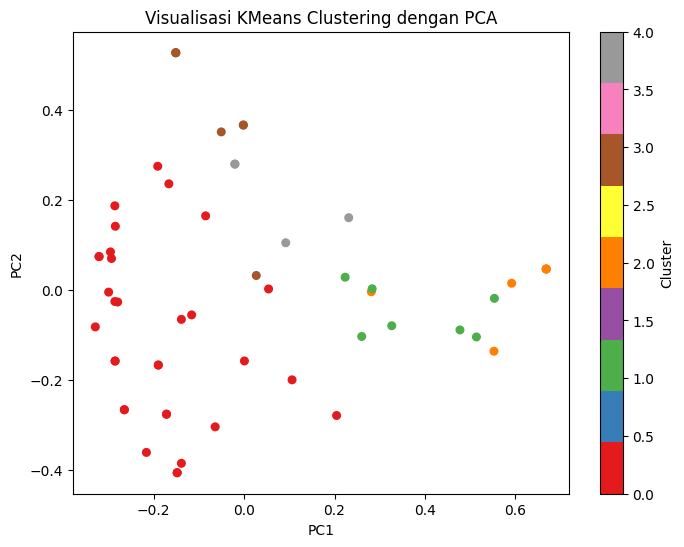

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='Set1', s=30)
plt.title("Visualisasi KMeans Clustering dengan PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.show()


# Analisis Topik Review Title

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def clean_text_simple(text):
    text = re.sub(r'[^\w\s]', '', str(text).lower())
    tokens = text.split()
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

df['clean_title'] = df['Review Title'].astype(str).apply(clean_text_simple)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize title
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['clean_title'])

# Fit LDA
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(X)

# Lihat topik
words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"\n🟦 Topic {idx}:")
    print(" ".join([words[i] for i in topic.argsort()[:-11:-1]]))



🟦 Topic 0:
phone smartphone better great looking thanks dual amazon gud worst

🟦 Topic 1:
good camera phone redmi pro excellent fantastic price device paid

🟦 Topic 2:
money best value phone battery quality mobile amazing super worth

🟦 Topic 3:
nice product awesome buy phone dont mobile service pro copy


C:\Users\71477\AppData\Local\Temp\ipykernel_23576\1356045848.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


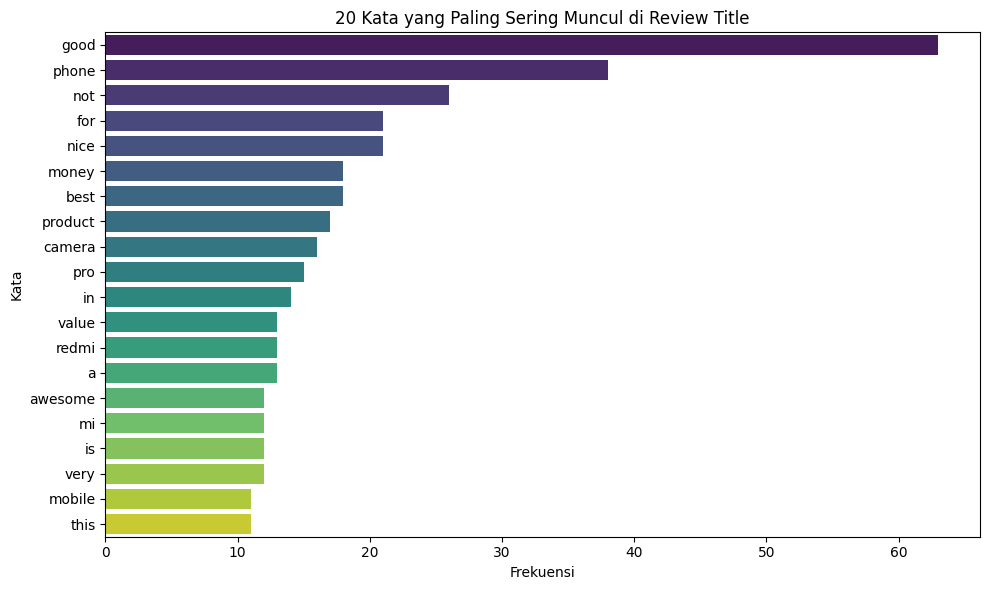

In [ ]:
from collections import Counter
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # hanya huruf
    return text

# 2. Gabungkan semua title
titles = df['Review Title'].dropna().apply(clean_text)

# 3. Tokenisasi dan hitung frekuensi
all_words = ' '.join(titles).split()
word_counts = Counter(all_words)
top_20 = word_counts.most_common(20)

# 4. Visualisasi
words, counts = zip(*top_20)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.title('20 Kata yang Paling Sering Muncul di Review Title')
plt.tight_layout()
plt.show()

# Analisis Tone Judul vs Isi Komentar

In [248]:
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis", model="finiteautomata/bertweet-base-sentiment-analysis")

# Apply ke judul
df['title_sentiment'] = df['Review Title'].apply(lambda x: sentiment_model(x)[0]['label'])

Device set to use cpu


In [249]:
# Sudah punya kolom bert_label (dari komentar), dan title_sentiment
sentiment_df = df[['title_sentiment', 'bert_label']].value_counts().reset_index()
sentiment_df.columns = ['Title Sentiment', 'Comment Sentiment', 'Count']
print(sentiment_df)

  Title Sentiment Comment Sentiment  Count
0             POS               POS    132
1             NEG               NEG     39
2             NEU               POS     37
3             NEU               NEU     23
4             POS               NEU     17
5             NEU               NEG     12
6             NEG               NEU      9
7             NEG               POS      6
8             POS               NEG      5


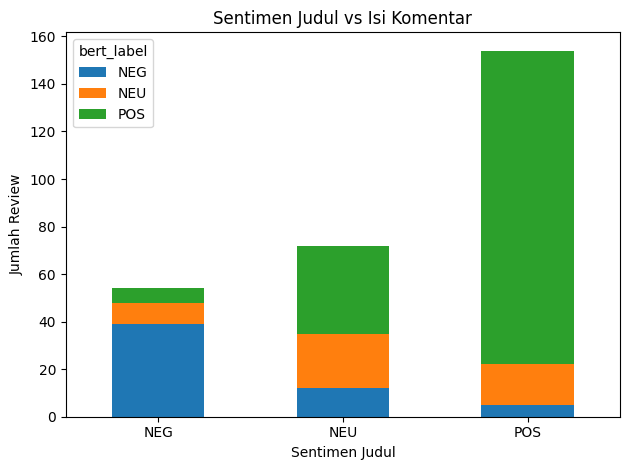

In [250]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.pivot_table(index='title_sentiment', columns='bert_label', aggfunc='size', fill_value=0)
pivot.plot(kind='bar', stacked=True)
plt.title('Sentimen Judul vs Isi Komentar')
plt.ylabel('Jumlah Review')
plt.xlabel('Sentimen Judul')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


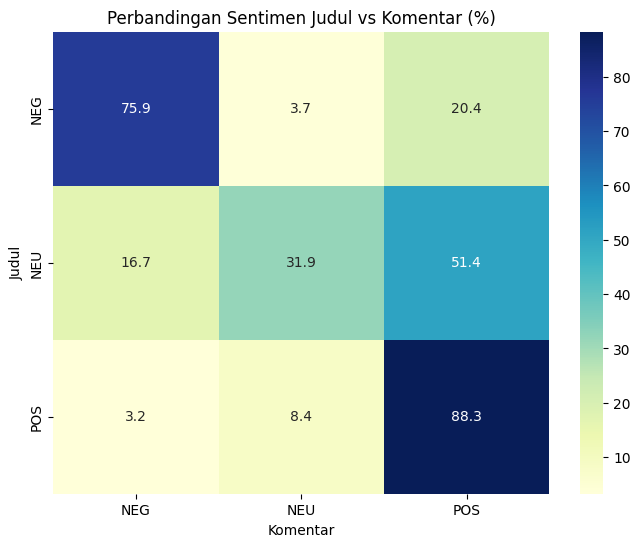

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab
sentiment_cross = pd.crosstab(df['title_sentiment'], df['comment_sentiment'], normalize='index') * 100

# Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(sentiment_cross, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perbandingan Sentimen Judul vs Komentar (%)")
plt.xlabel("Komentar")
plt.ylabel("Judul")
plt.show()


In [35]:
inconsistent_reviews = df[(df['title_sentiment'] == 'POS') & (df['comment_sentiment'] == 'NEG')]
inconsistent_reviews[['Review Title', 'Comments']]

,Review Title,Comments
22,Nice handy phone with good camera with notch,Like every things but fullscreen video playing...
79,Nice look,"Nice look with notch display, but sound is lit..."
81,Overall a nice phone,Sound quality is not so good\nEither way the m...
96,Very good desain,Sound qulity not dolby and processor performan...
259,Good for sharp use,Dislike snapdragon 425


In [36]:
neutral_to_negative = df[(df['title_sentiment'] == 'NEU') & (df['comment_sentiment'] == 'NEG')]
neutral_to_negative[['Review Title', 'Comments']]

,Review Title,Comments
27,Mi 6pro review,Camera clarity is not good and average mobile ...
39,Redmi Pro 6,"Awesome sound quality , battery life is good ,..."
49,Redmi Pro 6,"Awesome sound quality , battery life is good ,..."
56,Weste of money,Both Camera quality is bed.its price is too hi...
57,Dual 4G support,I have purchsed this item and two jio sim are ...
68,Missing part,disapointing
91,Look like I phn x. ????????????????????,No change in camera quality. Other functions s...
97,Not A camera fone,Looking wise sexy but camera quality is not wo...
103,No dual volte,I'm fan MI but No dual volte.. waste of money..
180,Handy,Slow charging


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Ambil fitur dan label dari judul
X = df['Review Title'].astype(str)
y = df['title_sentiment']

# Encode label (POS, NEU, NEG jadi angka)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

# Training
pipeline.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [39]:
from sklearn.metrics import classification_report

y_pred = pipeline.predict(X_test)
print("Evaluation (dibanding label judul):")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Evaluation (dibanding label judul):
              precision    recall  f1-score   support

         NEG       0.86      0.75      0.80         8
         NEU       0.80      0.25      0.38        16
         POS       0.73      1.00      0.84        32

    accuracy                           0.75        56
   macro avg       0.79      0.67      0.67        56
weighted avg       0.77      0.75      0.70        56



In [40]:
# Prediksi seluruh data pakai judul
df['predicted_title_sentiment'] = label_encoder.inverse_transform(pipeline.predict(X))

# Bandingkan ke label komentar
df['match_with_comment'] = df['predicted_title_sentiment'] == df['comment_sentiment']


In [41]:
# Persentase kecocokan
match_rate = df['match_with_comment'].mean() * 100
print(f"Cocok antara prediksi judul vs komentar: {match_rate:.2f}%")

# Contoh perbedaan
df_mismatch = df[df['match_with_comment'] == False][['Review Title', 'predicted_title_sentiment', 'comment_sentiment', 'Comments']]
df_mismatch.head()


Cocok antara prediksi judul vs komentar: 72.50%


,Review Title,predicted_title_sentiment,comment_sentiment,Comments
0,Another Midrange killer Smartphone by Xiaomi,NEG,POS,Another Midrange killer Smartphone by Xiaomi\n...
2,Full display not working in all application.,NEG,POS,Quite good
5,Redmi 6 pro (3/32 GB) review after using for o...,NEU,POS,Over prised by at least around Rs.1000/- Low l...
7,Fantastic,POS,NEU,Front camera is poor rest things are good
10,Another Midrange killer Smartphone by Xiaomi,NEG,POS,Another Midrange killer Smartphone by Xiaomi\n...


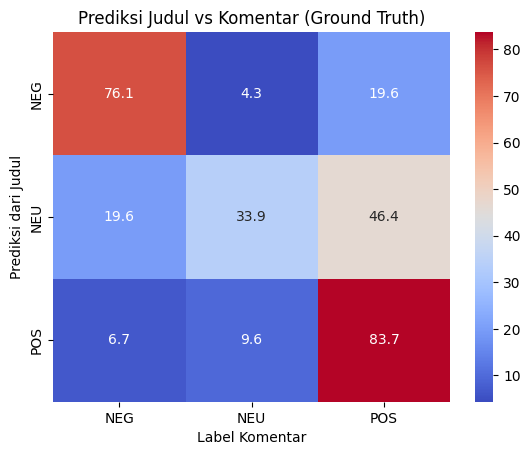

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    pd.crosstab(df['predicted_title_sentiment'], df['comment_sentiment'], normalize='index') * 100,
    annot=True, fmt=".1f", cmap='coolwarm'
)
plt.title("Prediksi Judul vs Komentar (Ground Truth)")
plt.ylabel("Prediksi dari Judul")
plt.xlabel("Label Komentar")
plt.show()


In [43]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Load tokenizer & model BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

# Fungsi untuk ekstraksi vektor dari judul
def get_bert_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    # Ambil representasi dari [CLS] token
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# Ambil data dan label
X = df['Review Title'].astype(str).tolist()
y = df['comment_sentiment']

# Ambil embedding
X_embeddings = np.array([get_bert_embedding(text) for text in X])

# Split dan train logistic regression
X_train, X_test, y_train, y_test = train_test_split(X_embeddings, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


              precision    recall  f1-score   support

         NEG       0.67      0.77      0.71        13
         NEU       0.25      0.25      0.25         4
         POS       0.89      0.85      0.87        39

    accuracy                           0.79        56
   macro avg       0.60      0.62      0.61        56
weighted avg       0.79      0.79      0.79        56



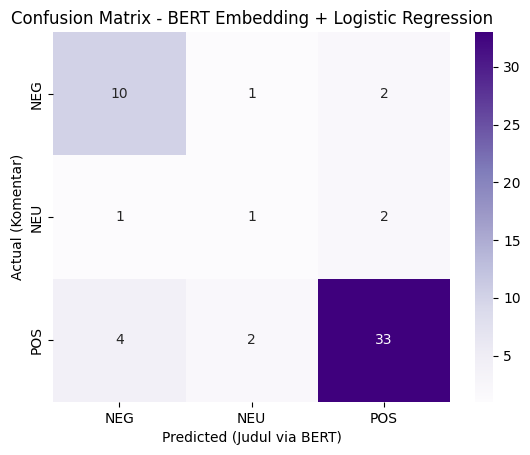

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['NEG', 'NEU', 'POS'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['NEG', 'NEU', 'POS'], yticklabels=['NEG', 'NEU', 'POS'])
plt.xlabel("Predicted (Judul via BERT)")
plt.ylabel("Actual (Komentar)")
plt.title("Confusion Matrix - BERT Embedding + Logistic Regression")
plt.show()


              precision    recall  f1-score   support

         NEG       0.67      0.77      0.71        13
         NEU       0.25      0.25      0.25         4
         POS       0.89      0.85      0.87        39

    accuracy                           0.79        56
   macro avg       0.60      0.62      0.61        56
weighted avg       0.79      0.79      0.79        56



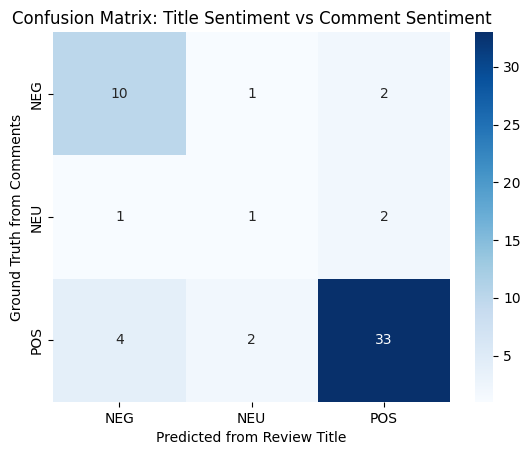

In [46]:
# Laporan klasifikasi
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['NEG', 'NEU', 'POS'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NEG', 'NEU', 'POS'], yticklabels=['NEG', 'NEU', 'POS'])
plt.xlabel("Predicted from Review Title")
plt.ylabel("Ground Truth from Comments")
plt.title("Confusion Matrix: Title Sentiment vs Comment Sentiment")
plt.show()

# Feature Engineering TF-IDF + Sentiment Score

##### Hybrid feature engineering: menggabungkan representasi teks (TF-IDF) dengan makna sentimen (score) → sering jadi kombinasi kuat apabila data tidak besar.

In [251]:
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.sparse import hstack
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\71477\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [252]:
df['Comments'] = df['Comments'].astype(str)
df['label'] = df['bert_label']


In [253]:
sia = SentimentIntensityAnalyzer()

# Hitung compound sentiment score
df['sentiment_score'] = df['Comments'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [254]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['Comments'])


In [255]:
from scipy.sparse import csr_matrix

# Skala sentiment_score ke bentuk sparse matrix
sent_score_sparse = csr_matrix(df['sentiment_score'].values.reshape(-1,1))

# Gabungkan
X_combined = hstack([X_tfidf, sent_score_sparse])
y = df['label']

In [256]:
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [257]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Kalau labelnya >2 kelas, gunakan average='macro'
y_prob = model.predict_proba(X_test)
print("ROC AUC (macro):", roc_auc_score(pd.get_dummies(y_test), y_prob, average='macro'))

              precision    recall  f1-score   support

         NEG       0.71      0.38      0.50        13
         NEU       0.67      0.33      0.44         6
         POS       0.80      1.00      0.89        37

    accuracy                           0.79        56
   macro avg       0.73      0.57      0.61        56
weighted avg       0.77      0.79      0.75        56

[[ 5  1  7]
 [ 2  2  2]
 [ 0  0 37]]
ROC AUC (macro): 0.9659063988194956


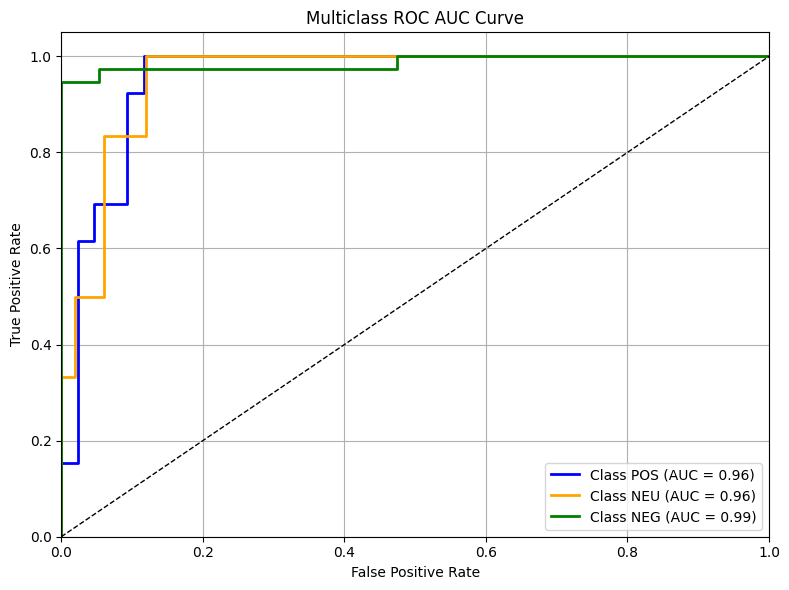

In [258]:
from itertools import cycle
# Pastikan y_test dan y_pred_proba sudah tersedia
classes = sorted(df['label'].unique())  # misalnya: [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)  # binarize true labels
y_score = model.predict_proba(X_test)  # predicted probabilities
n_classes = y_score.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'orange', 'green'])
class_names = ['POS', 'NEU', 'NEG']  # urutannya harus sesuai mapping label

plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC AUC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


# Hybrid BERT Embeddings + Sentiment Score

In [259]:
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
model = BertModel.from_pretrained("bert-base-multilingual-cased")
model.eval()

def get_bert_embeddings(text_list):
    embeddings = []
    with torch.no_grad():
        for text in tqdm(text_list):
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
            outputs = model(**inputs)
            cls_vector = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
            embeddings.append(cls_vector)
    return np.array(embeddings)

comments = df['Comments'].astype(str).tolist()
bert_vectors = get_bert_embeddings(comments)

100%|██████████| 280/280 [00:10<00:00, 27.13it/s]


In [260]:
from textblob import TextBlob

def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity  # dari -1 (negatif) sampai 1 (positif)

sentiment_scores = df['Comments'].astype(str).apply(get_sentiment_score).values.reshape(-1, 1)


In [261]:
from sklearn.preprocessing import StandardScaler

X_bert_sentiment = np.hstack([bert_vectors, sentiment_scores])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bert_sentiment)

y = df['bert_label']


In [262]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

         NEG       0.60      0.69      0.64        13
         NEU       0.67      1.00      0.80         6
         POS       0.91      0.78      0.84        37

    accuracy                           0.79        56
   macro avg       0.72      0.83      0.76        56
weighted avg       0.81      0.79      0.79        56

[[ 9  1  3]
 [ 0  6  0]
 [ 6  2 29]]


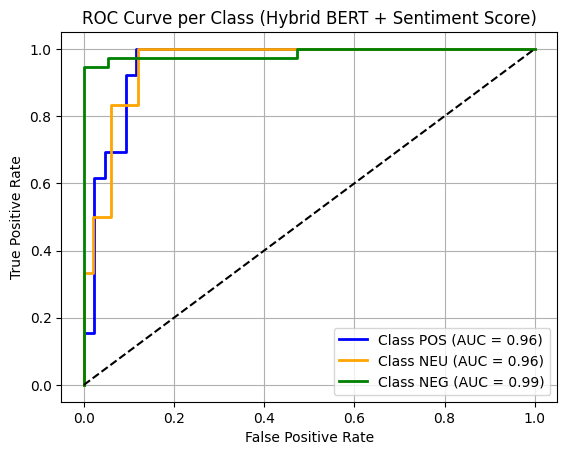

In [263]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Binarize labels untuk multiclass ROC
classes = clf.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(X_test)

# Plot ROC tiap kelas

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class (Hybrid BERT + Sentiment Score)')
plt.legend()
plt.grid()
plt.show()


# Analisis Feedback dari Kolom Useful

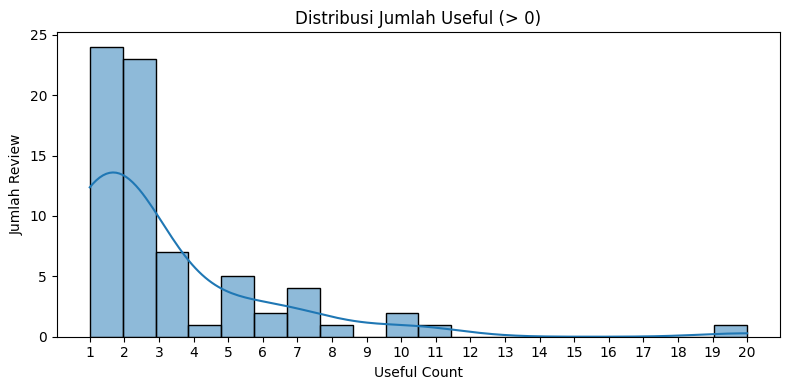

In [264]:
# Filter hanya yang useful_count > 0
filtered_df = df[df['useful_count'] > 0]

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(filtered_df['useful_count'], bins=20, kde=True)
plt.title("Distribusi Jumlah Useful (> 0)")
plt.xlabel("Useful Count")
plt.ylabel("Jumlah Review")
plt.xticks(ticks=range(1, filtered_df['useful_count'].max() + 1))  # tanpa nol
plt.tight_layout()
plt.show()


In [265]:
print(df['Useful'].unique())

[' ' '7 people found this helpful' '2 people found this helpful'
 '6 people found this helpful' '3 people found this helpful'
 '5 people found this helpful' '4 people found this helpful'
 'One person found this helpful' nan '10 people found this helpful'
 '8 people found this helpful' '11 people found this helpful'
 '20 people found this helpful']


In [266]:
df[df['useful_count'] > 6][['Useful','Review Title', 'Rating','Comments', 'bert_label']]

,Useful,Review Title,Rating,Comments,bert_label
1,7 people found this helpful,vry small size mobile,3.0 out of 5 stars,All ok but vry small size mobile,NEU
2,7 people found this helpful,Full display not working in all application.,3.0 out of 5 stars,Quite good,POS
11,7 people found this helpful,vry small size mobile,3.0 out of 5 stars,All ok but vry small size mobile,NEU
12,7 people found this helpful,Full display not working in all application.,3.0 out of 5 stars,Quite good,POS
220,10 people found this helpful,#Horrible experience of Redmi 6pro - Readon to...,1.0 out of 5 stars,Please don't buy!!\n\nHorrible phone from Xiao...,NEU
223,10 people found this helpful,Worst Camera,2.0 out of 5 stars,Front camera of this phone is like a VGA camer...,NEG
224,8 people found this helpful,This mobile is defective,1.0 out of 5 stars,I say this product is very defective camera is...,NEG
225,11 people found this helpful,Camera not good,1.0 out of 5 stars,Not good photo crirati,NEG
242,20 people found this helpful,Best phone forever.,5.0 out of 5 stars,Best phone with face unlock full hd video reco...,POS


In [267]:
df_useful = df[df['useful_count'] > 0]

# Buat salinan dulu agar aman
df_useful = df_useful.copy()

# Ambil angka rating dari string dan ubah ke integer
df_useful['Rating_clean'] = df_useful['Rating'].astype(str).str.extract(r'(\d+)').astype(int) - 1



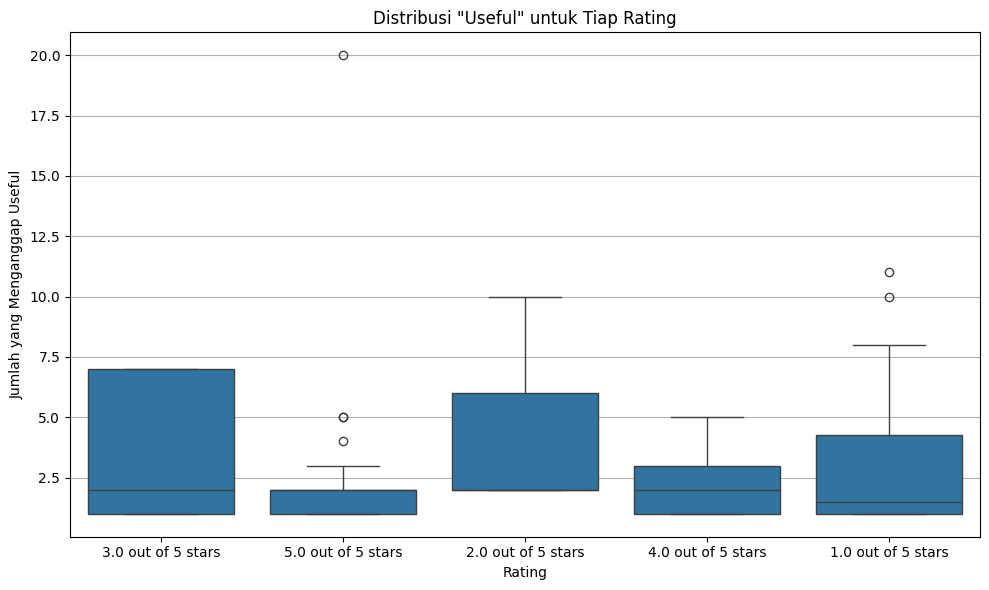

Korelasi Pearson: -0.11676590369352927
Korelasi Spearman: -0.06591838068296434


In [268]:
# Boxplot Rating vs Useful
plt.figure(figsize=(10,6))
sns.boxplot(x='Rating', y='useful_count', data=df_useful)
plt.title('Distribusi "Useful" untuk Tiap Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah yang Menganggap Useful')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Korelasi numerik
print("Korelasi Pearson:",df_useful['Rating_clean'].corr(df_useful['useful_count'], method='pearson'))
print("Korelasi Spearman:", df_useful['Rating_clean'].corr(df_useful['useful_count'], method='spearman'))

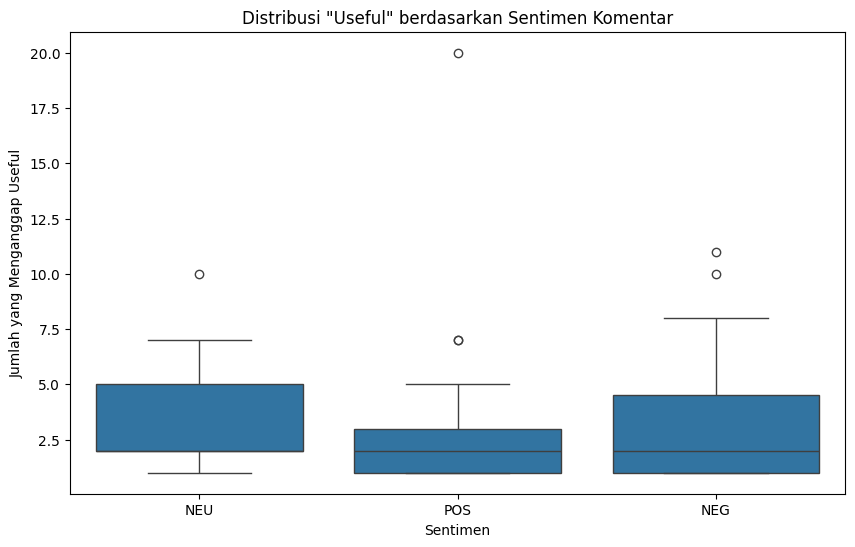

In [269]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='bert_label', y='useful_count', data=df_useful)
plt.title('Distribusi "Useful" berdasarkan Sentimen Komentar')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah yang Menganggap Useful')
plt.show()


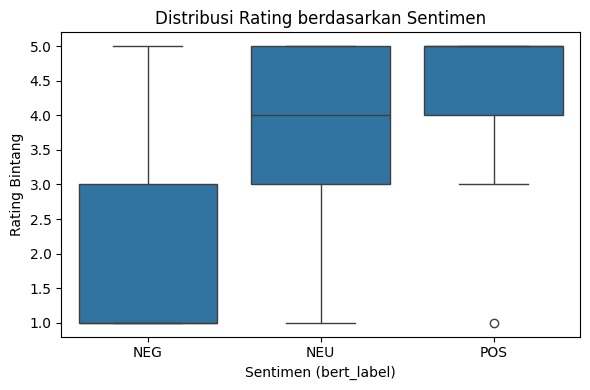

In [272]:
import seaborn as sns
import matplotlib.pyplot as plt

# Urutan label sentimen
sentiment_order = ['NEG', 'NEU', 'POS']

# Boxplot: distribusi rating per sentimen
plt.figure(figsize=(6, 4))
sns.boxplot(x='bert_label', y='Rating_clean', data=df, order=sentiment_order)
plt.title("Distribusi Rating berdasarkan Sentimen")
plt.xlabel("Sentimen (bert_label)")
plt.ylabel("Rating Bintang")
plt.tight_layout()
plt.show()


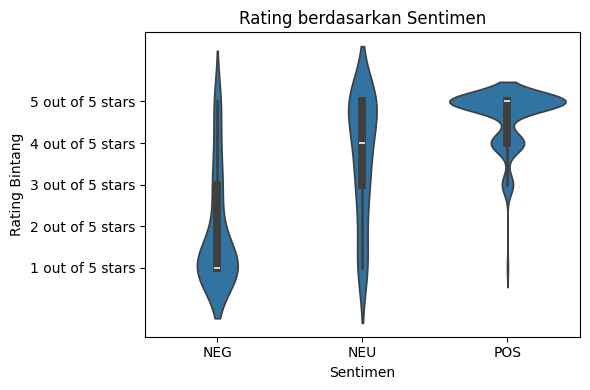

In [283]:
# VIOLIN PLOT
plt.figure(figsize=(6, 4))
sns.violinplot(x='bert_label', y='Rating_clean', data=df, order=['NEG', 'NEU', 'POS'])

plt.title("Rating berdasarkan Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Rating Bintang")


# Atur ulang label manual dari 5 ke 1
plt.yticks(ticks=[5, 4, 3, 2, 1], labels=["5 out of 5 stars", "4 out of 5 stars", "3 out of 5 stars", "2 out of 5 stars", "1 out of 5 stars"])

plt.tight_layout()
plt.show()


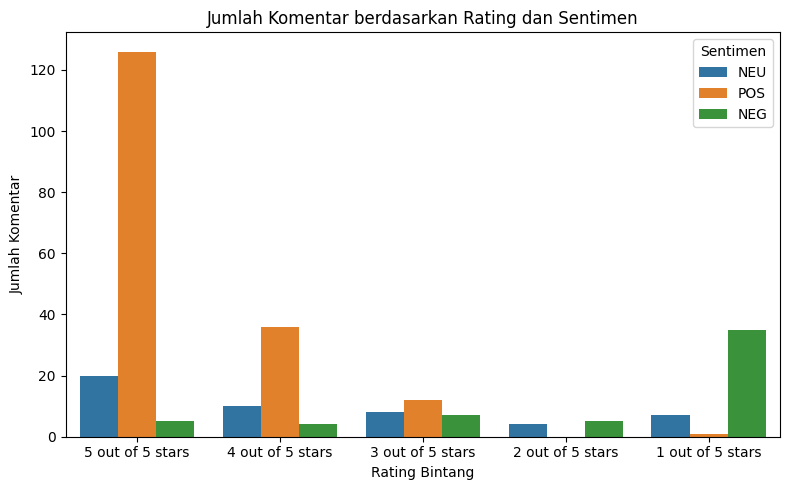

In [292]:
import seaborn as sns
import matplotlib.pyplot as plt

# Konversi rating ke tipe kategorikal dengan urutan dari 5 ke 1
df['Rating_Cat'] = pd.Categorical(df['Rating_clean'], categories=[5, 4, 3, 2, 1], ordered=True)

# Buat countplot dengan urutan batang dari 5 → 1
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating_Cat', hue='bert_label', data=df)

plt.title("Jumlah Komentar berdasarkan Rating dan Sentimen")
plt.xlabel("Rating Bintang")
plt.ylabel("Jumlah Komentar")

# Label X-axis yang rapi
plt.xticks(
    ticks=range(5),
    labels=["5 out of 5 stars", "4 out of 5 stars", "3 out of 5 stars", "2 out of 5 stars", "1 out of 5 stars"]
)

plt.legend(title="Sentimen")
plt.tight_layout()
plt.show()


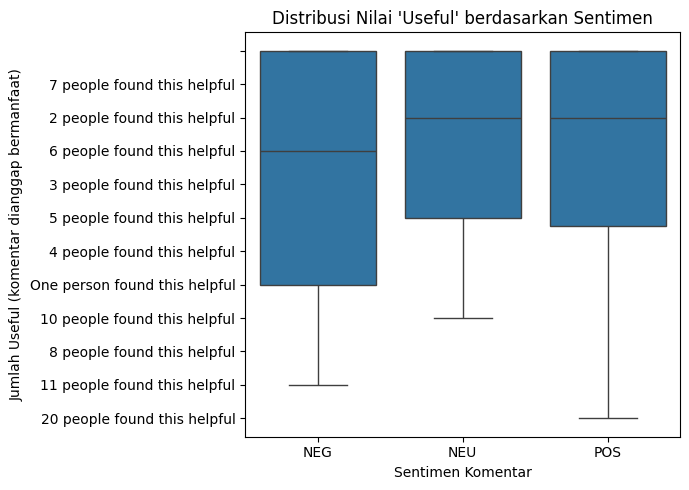

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.boxplot(x='bert_label', y='Useful', data=df, order=['NEG', 'NEU', 'POS'])

plt.title("Distribusi Nilai 'Useful' berdasarkan Sentimen")
plt.xlabel("Sentimen Komentar")
plt.ylabel("Jumlah Useful (komentar dianggap bermanfaat)")
plt.tight_layout()
plt.show()


# Analisis Sentimen

C:\Users\71477\AppData\Local\Temp\ipykernel_23576\3516144431.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')


bert_label
POS    175
NEG     56
NEU     49
Name: count, dtype: int64


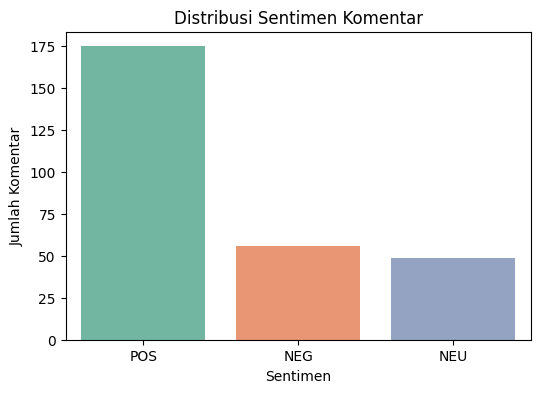

Persentase tiap label:
bert_label
POS    62.5
NEG    20.0
NEU    17.5
Name: count, dtype: float64

Komentar paling positif:
                                              Comments  bert_score
70   Powerful device I love mi ...thnax Amazon for ...    0.993062
252  Osm product\nAmazon is better then flipkart I ...    0.992854
74   I love amezon\nGood packing\nGood product\nCam...    0.992818
246  I loved the fact that Lenovo gave me such a ni...    0.992790
236  I loved the fact that Lenovo gave me such a ni...    0.992790

Komentar paling negatif:
                                              Comments  bert_score
138                  worst product ever. don't buy it.    0.983391
55   Worst phone from MI and Amazon\nTouch was not ...    0.982976
218  It has a worst front camera I have ever seen o...    0.982743
235  Very poor quality in front facing camera, and ...    0.981815
245  Very poor quality in front facing camera, and ...    0.981815


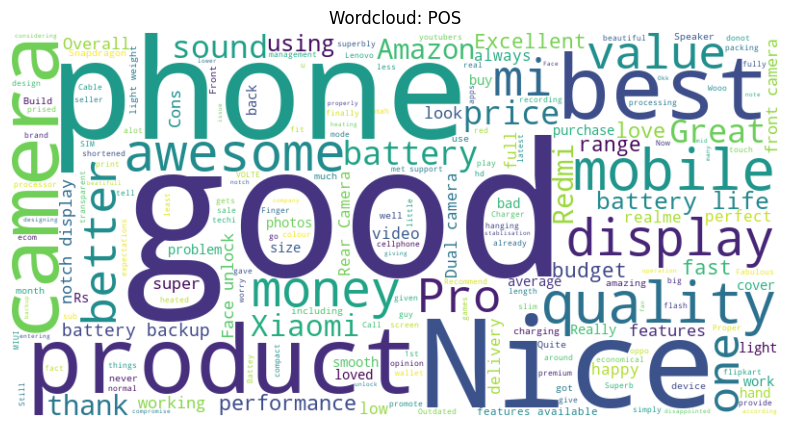

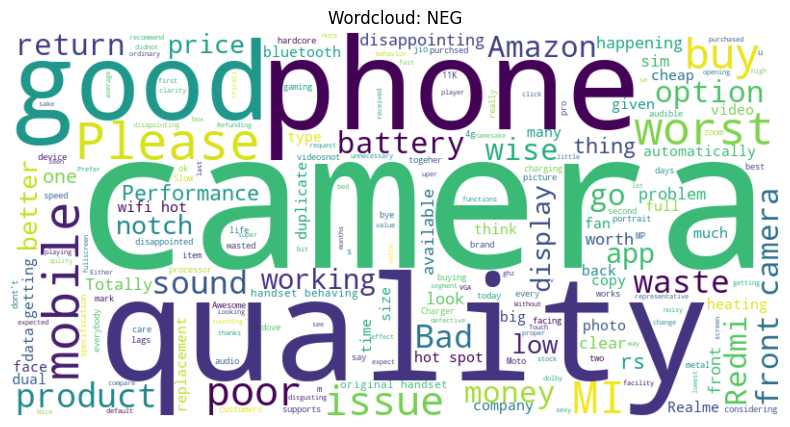

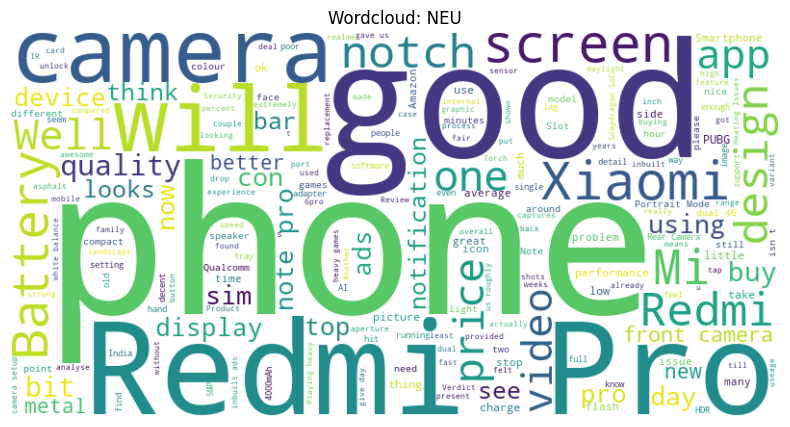

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Cek distribusi sentimen
sentiment_counts = df['bert_label'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.title("Distribusi Sentimen Komentar")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")
plt.show()

# 4. Persentase tiap sentimen
print("Persentase tiap label:")
print((sentiment_counts / sentiment_counts.sum() * 100).round(2))

# 5. Tampilkan 5 komentar paling positif & negatif (berdasarkan score)
print("\nKomentar paling positif:")
print(df[df['bert_label'] == 'POS'].sort_values(by='bert_score', ascending=False).head(5)[['Comments', 'bert_score']])

print("\nKomentar paling negatif:")
print(df[df['bert_label'] == 'NEG'].sort_values(by='bert_score', ascending=False).head(5)[['Comments', 'bert_score']])

# 6. Wordcloud per sentimen
def generate_wordcloud(sentiment):
    text = " ".join(df[df['bert_label'] == sentiment]['Comments'].dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Wordcloud: {sentiment}")
    plt.show()

generate_wordcloud("POS")
generate_wordcloud("NEG")
generate_wordcloud("NEU")


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_counts)


LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
def display_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\n🔹 Topik {topic_idx + 1}:")
        print(" | ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

feature_names = vectorizer.get_feature_names_out()
display_topics(lda, feature_names)



🔹 Topik 1:
mi | not | worst | of | but | fan | from | camera | and | no

🔹 Topik 2:
not | this | is | of | and | phone | in | are | but | mobile

🔹 Topik 3:
issue | charging | slow | customers | care | is | option | but | not | like

🔹 Topik 4:
is | camera | the | phone | for | good | quality | this | very | wise

🔹 Topik 5:
not | camera | is | good | quality | do | buy | bad | please | but


# Analisis Sentimen

C:\Users\71477\AppData\Local\Temp\ipykernel_23576\3516144431.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')


bert_label
POS    175
NEG     56
NEU     49
Name: count, dtype: int64


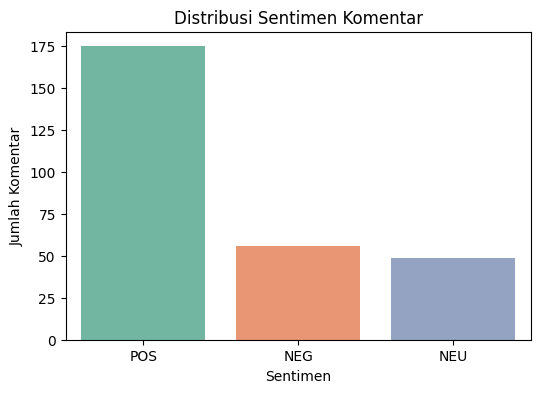

Persentase tiap label:
bert_label
POS    62.5
NEG    20.0
NEU    17.5
Name: count, dtype: float64

Komentar paling positif:
                                              Comments  bert_score
70   Powerful device I love mi ...thnax Amazon for ...    0.993062
252  Osm product\nAmazon is better then flipkart I ...    0.992854
74   I love amezon\nGood packing\nGood product\nCam...    0.992818
246  I loved the fact that Lenovo gave me such a ni...    0.992790
236  I loved the fact that Lenovo gave me such a ni...    0.992790

Komentar paling negatif:
                                              Comments  bert_score
138                  worst product ever. don't buy it.    0.983391
55   Worst phone from MI and Amazon\nTouch was not ...    0.982976
218  It has a worst front camera I have ever seen o...    0.982743
235  Very poor quality in front facing camera, and ...    0.981815
245  Very poor quality in front facing camera, and ...    0.981815


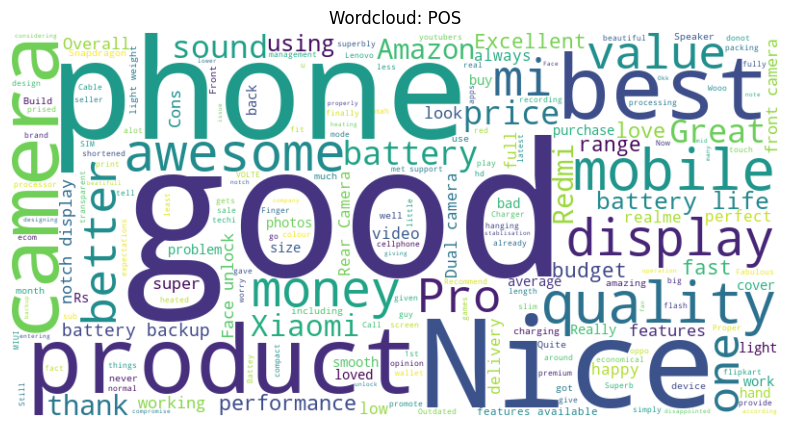

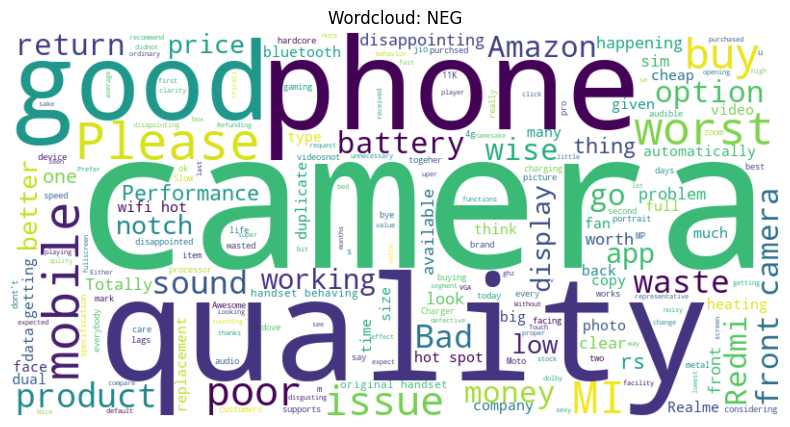

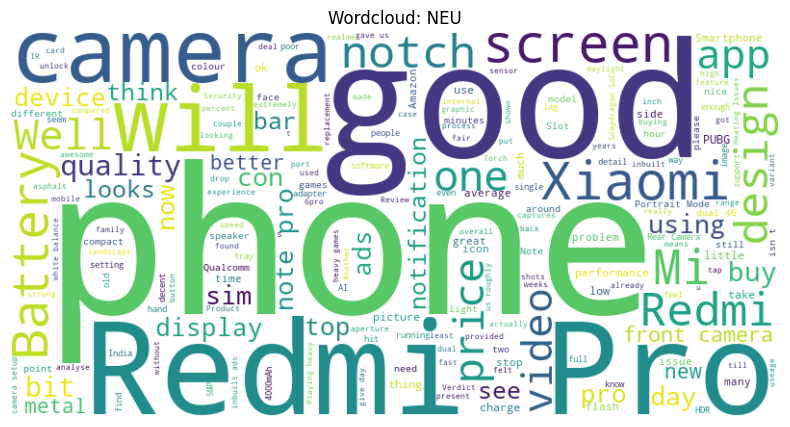

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Cek distribusi sentimen
sentiment_counts = df['bert_label'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.title("Distribusi Sentimen Komentar")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")
plt.show()

# 4. Persentase tiap sentimen
print("Persentase tiap label:")
print((sentiment_counts / sentiment_counts.sum() * 100).round(2))

# 5. Tampilkan 5 komentar paling positif & negatif (berdasarkan score)
print("\nKomentar paling positif:")
print(df[df['bert_label'] == 'POS'].sort_values(by='bert_score', ascending=False).head(5)[['Comments', 'bert_score']])

print("\nKomentar paling negatif:")
print(df[df['bert_label'] == 'NEG'].sort_values(by='bert_score', ascending=False).head(5)[['Comments', 'bert_score']])

# 6. Wordcloud per sentimen
def generate_wordcloud(sentiment):
    text = " ".join(df[df['bert_label'] == sentiment]['Comments'].dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Wordcloud: {sentiment}")
    plt.show()

generate_wordcloud("POS")
generate_wordcloud("NEG")
generate_wordcloud("NEU")
